In [228]:
import numpy as np
import matplotlib.pyplot as plt
import pyaudio
import os

## Messung

In [229]:
def trigger_signal(signal, threshold, rate):
    start_index = None
    for i, value in enumerate(signal):
        if abs(value) > threshold:
            start_index = i
            break
    
    if start_index is None:
        # Kein Trigger erkannt
        return np.array([], dtype=np.int16)  # Leeres Signal zurückgeben

    # Trigger-Endpunkt finden
    end_index = len(signal)  # Standardmäßig bis zum Ende des Signals
    for i in range(start_index, len(signal)):
        # Wenn die Amplitude wieder unter den Schwellenwert fällt und konstant bleibt
        if abs(signal[i]) <= threshold and all(abs(signal[i:i+int(rate*0.1)]) <= threshold):
            end_index = i
            break

    # Signal zuschneiden
    trimmed_signal = signal[start_index:end_index]

    return trimmed_signal

In [230]:
def record(FILENAME):
    FORMAT = pyaudio.paInt16
    CHANNELS = 1
    RATE = 44100
    RECORD_SECONDS = 1
    THRESHOLD = 50

    p = pyaudio.PyAudio()
    stream = p.open(format=FORMAT, channels=CHANNELS, rate=RATE, input=True, frames_per_buffer=1024)

    print("Aufnahme startet...")
    frames = []
    for _ in range(0, int(RATE / 1024 * RECORD_SECONDS)):
        data = stream.read(1024)
        frames.append(np.frombuffer(data, dtype=np.int16))

    print("Aufnahme beendet.")
    stream.stop_stream()
    stream.close()
    p.terminate()

    signal = np.concatenate(frames)
    triggered_signal = trigger_signal(signal, THRESHOLD, RATE)
    np.save(FILENAME, triggered_signal)
    print(f"Signal gespeichert als {FILENAME}")

### Aufnahme

In [231]:
def plot_signal(FILENAME):
    signal = np.load(FILENAME)
    plt.figure(figsize=(20, 4))
    plt.plot(signal)
    plt.title('Audio-Signal')
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

Aufnahme startet...
Aufnahme beendet.
Signal gespeichert als rechts-5.npy


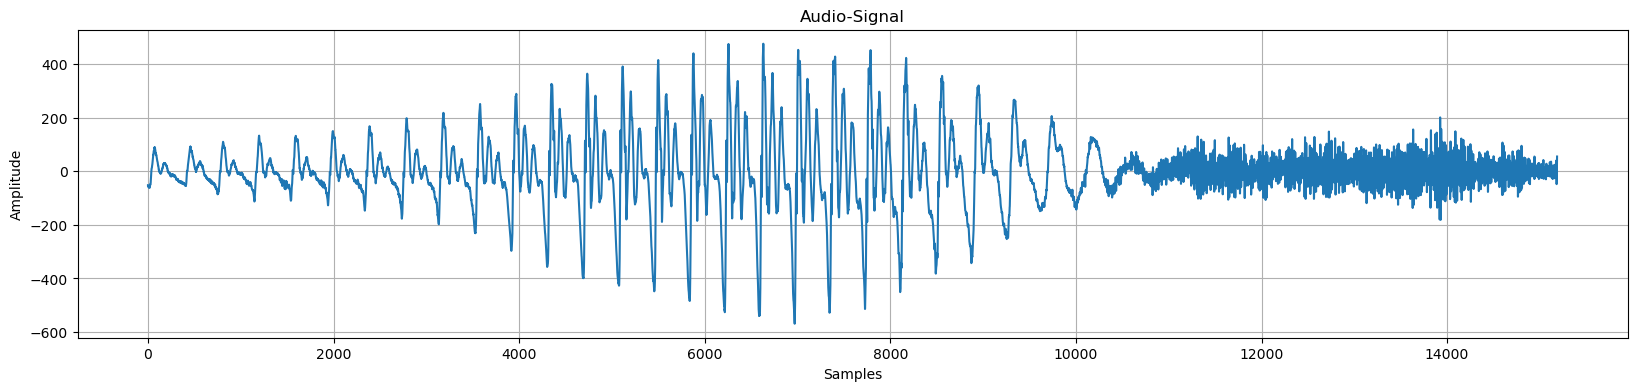

In [323]:
name = 'rechts-5' + '.npy'
record(name)
plot_signal(name)